#Data Warehouse and OLAP

In [ ]:
!python --version

Python 3.10.12


## What is a data warehouse?

> “A data warehouse is a subject ‐oriented, integrated, time ‐variant, and nonvolatile collection of data in support of management’s decision ‐making process [Inm96].” — W. H. Inmon



**What is a data warehouse exactly? **

Simply it is a decision support database that is maintained separately from the organization’s operational database. And it is a repository of information collected from multiple sources, stored under a unified schema, and that usually resides at a single site. A data warehouse further identified as a semantically consistent data store that serves as a physical implementation of a decision support data model and stores the information on which an enterprise needs to make strategic decisions.



Let’s take a closer look at each of the key features of a data warehouse;

*  **Subject-oriented**: A data warehouse is organized around major subjects such as customer, supplier, product, and sales. Rather than concentrating on the day-to-day operations and transaction processing of an organization, a data warehouse focuses on the modeling and analysis of data for decision-makers.
*  **Integrated**: A data warehouse is usually constructed by integrating multiple heterogeneous sources, such as relational databases, flat files, and online transaction records. Data cleaning and data integration techniques are applied to ensure consistency in naming conventions, encoding structures, attribute measures, and so on.
*  **Time-variant**: Data is stored to provide information from a historic perspective (e.g., the past 5–10 years). Every key structure in the data warehouse contains, either implicitly or explicitly, a time element.
*  **Nonvolatile**: A data warehouse is always a physically separate store of data transformed from the application data found in the operational environment. Due to this separation, a data warehouse does not require transaction processing, recovery, and concurrency control mechanisms. It usually requires only two operations in data accessing: initial loading of data and access to data.

OLAP : *On-line Analytical Processing*

OLAP stands for On-Line Analytical Processing. OLAP is a classification of software technology which authorizes analysts, managers, and executives to gain insight into information through fast, consistent, interactive access in a wide variety of possible views of data that has been transformed from raw information to reflect the real dimensionality of the enterprise as understood by the clients.

OLAP implement the multidimensional analysis of business information and support the capability for complex estimations, trend analysis, and sophisticated data modeling.

Fundamentally, OLAP has a very simple concept. It pre-calculates most of the queries that are typically very hard to execute over tabular databases, namely aggregation, joining, and grouping. These queries are calculated during a process that is usually called 'building' or 'processing' of the OLAP cube.

## Data Warehouse Modeling: Data Cube and OLAP

Data warehouses and OLAP tools are based on a multidimensional data model. This model views data in the form of a data cube.

A data cube allows data to be modeled and viewed in multiple dimensions. It is defined by dimensions and facts.

*  *Dimensions*: dimensions are the perspectives or entities with respect to which an organization wants to keep records. Each dimension may have a table associated with it, called a dimension table, which further describes the dimension.
*  *Facts*: Facts are numeric measures. The fact table contains the names of the facts, or measures, as well as keys to each of the related dimension tables.

The multidimensional model of a data warehouse can be modeled in the form of a star schema, a snowflake schema, or a fact constellation schema.

- *Star schema*: A fact table in the middle connected to a set of dimension tables

- *Snowflake schema*: A refinement of star schema where some dimensional hierarchy is normalized into a set of smaller dimension tables, forming a shape similar to a snowflake.

- *fact constellation schema*: Multiple fact tables share dimension tables, viewed as a collection of stars, therefore called galaxy schema or fact constellation.

Star Schema

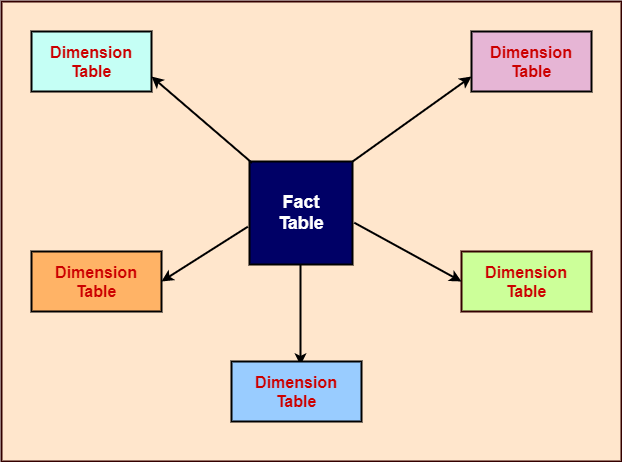

Snowflake Schema

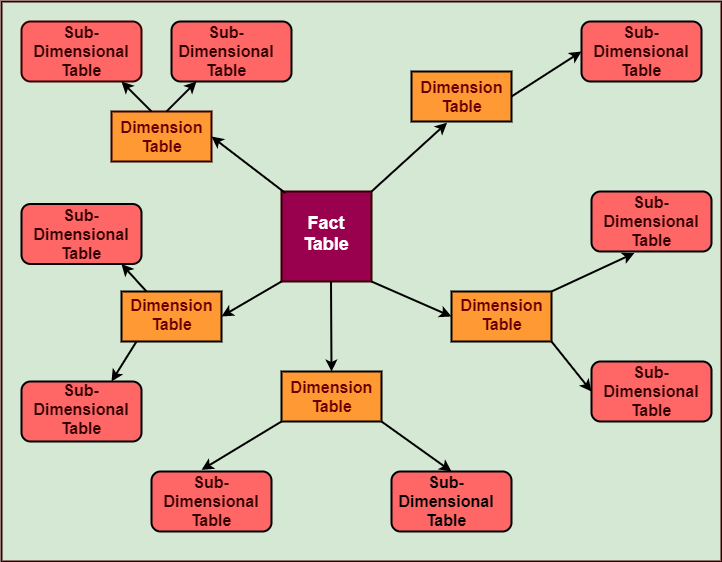

Fact Constellation Schema / Gallaxy Schema

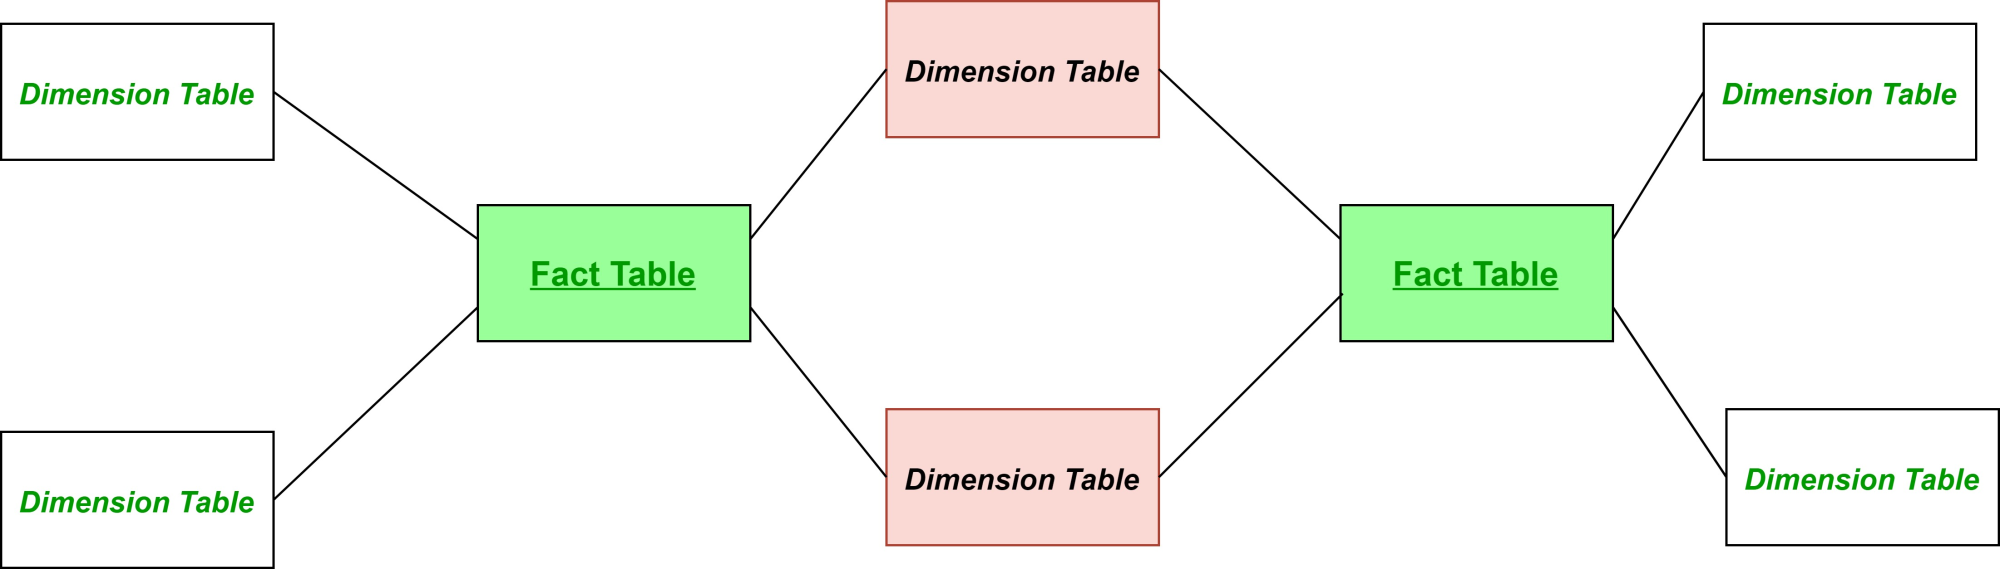

##**Measures**
A data cube measure is a numeric function that can be evaluated at each point in the data cube space. A measure value is computed for a given point by aggregating the data corresponding to the respective dimension–value pairs defining the given point. Measures can be organized into three categories as distributive, algebraic, and holistic based on the kind of aggregate functions used.

*  **Distributive**: If the result derived by applying the function to n aggregate values is the same as that derived by applying the function on all the data without partitioning. **E.g., count(), sum(), min(), max()**
* **Algebraic**: If it can be computed by an algebraic function with M arguments (where M is a bounded integer), each of which is obtained by applying a distributive aggregate function. **E.g., avg(), min_N(), standard_deviation()**
* **Holistic**: If there is no constant bound on the storage size needed to describe a sub aggregate. **E.g., median(), mode(), rank()**

#Example 1

In [ ]:
!pip install pandas

In [ ]:
import pandas as pd
import numpy as np


In [ ]:

# Crear datos de ejemplo
data = {
    'Fecha': pd.date_range('2024-01-01', periods=100, freq='D'),
    'Producto': np.random.choice(['Producto A', 'Producto B', 'Producto C'], size=100),
    'Tienda': np.random.choice(['Tienda 1', 'Tienda 2', 'Tienda 3'], size=100),
    'Region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], size=100),
    'Ventas': np.random.uniform(100, 1000, size=100),  # Ventas en unidades monetarias
    'Cantidad': np.random.randint(1, 10, size=100)  # Cantidad de productos vendidos
}

# Crear un DataFrame de Pandas
df = pd.DataFrame(data)
print(df)

# Crear un cubo con datos del df
cubo = pd.pivot_table(df,
                      values=['Ventas', 'Cantidad'],  # Medidas
                      index=['Fecha', 'Producto', 'Tienda','Region'],  # Dimensiones
                      aggfunc={'Ventas': 'sum', 'Cantidad': 'sum'},  # Función de agregación
                      fill_value=0)  # Rellenar valores vacíos con 0
cubo.head(10)

        Fecha    Producto    Tienda Region      Ventas  Cantidad
0  2024-01-01  Producto B  Tienda 2    Sur  137.633225         5
1  2024-01-02  Producto C  Tienda 1  Norte  305.601948         2
2  2024-01-03  Producto B  Tienda 2    Sur  103.142692         2
3  2024-01-04  Producto B  Tienda 2  Oeste  767.049680         5
4  2024-01-05  Producto A  Tienda 1  Norte  900.953902         7
..        ...         ...       ...    ...         ...       ...
95 2024-04-05  Producto C  Tienda 2   Este  696.042116         1
96 2024-04-06  Producto B  Tienda 1  Norte  364.105818         5
97 2024-04-07  Producto C  Tienda 2  Oeste  370.482279         8
98 2024-04-08  Producto B  Tienda 2  Oeste  198.674794         6
99 2024-04-09  Producto B  Tienda 3    Sur  726.424952         5

[100 rows x 6 columns]


,,,,Cantidad,Ventas
Fecha,Producto,Tienda,Region,,
2024-01-01,Producto B,Tienda 2,Sur,5,137.633225
2024-01-02,Producto C,Tienda 1,Norte,2,305.601948
2024-01-03,Producto B,Tienda 2,Sur,2,103.142692
2024-01-04,Producto B,Tienda 2,Oeste,5,767.049680
2024-01-05,Producto A,Tienda 1,Norte,7,900.953902
2024-01-06,Producto C,Tienda 2,Norte,3,435.825194
2024-01-07,Producto C,Tienda 1,Este,5,750.276672
2024-01-08,Producto B,Tienda 1,Oeste,5,964.716783
2024-01-09,Producto C,Tienda 3,Este,1,479.940455


In [ ]:
#4. Realizar operaciones básicas sobre el cubo
#Podemos realizar varias operaciones sobre el cubo, como sumar, filtrar y modificar los datos.

#A. Roll-up
#Ejemplo: Sumar las ventas totales por tienda

ventas_por_tienda = cubo.groupby('Tienda')['Ventas'].sum()
ventas_por_tienda

,Ventas
Tienda,
Tienda 1,15788.287182
Tienda 2,20609.714653
Tienda 3,16046.700584


In [ ]:
#B. Dice
#Ejemplo: Filtrar por producto y obtener las ventas por tienda
# Filtrar por producto
ventas_producto_a = cubo.loc[(slice(None), 'Producto A', slice(None)), ['Ventas']]

# Mostrar las ventas de "Producto A" por tienda
ventas_producto_a

,,,,Ventas
Fecha,Producto,Tienda,Region,
2024-01-05,Producto A,Tienda 1,Norte,900.953902
2024-01-12,Producto A,Tienda 2,Sur,161.417626
2024-01-15,Producto A,Tienda 1,Oeste,630.571001
2024-01-24,Producto A,Tienda 2,Norte,726.174611
2024-01-27,Producto A,Tienda 3,Sur,220.676490
2024-01-30,Producto A,Tienda 2,Este,554.839695
2024-02-02,Producto A,Tienda 1,Sur,856.712000
2024-02-05,Producto A,Tienda 3,Sur,289.434805
2024-02-06,Producto A,Tienda 2,Oeste,855.145373


In [ ]:
#Slice and Roll-up:
# Encontrar el producto con más ventas (por suma total)
producto_mas_vendido = cubo.groupby('Producto')['Ventas'].sum().idxmax()
producto_mas_vendido

'Producto C'

In [ ]:
#C. Drill-down
# Obtener las ventas totales por región y fecha
ventas_por_region = cubo.groupby('Region')['Ventas'].sum()
ventas_por_region

,Ventas
Region,
Este,13505.234170
Norte,9564.152545
Oeste,18426.396938
Sur,10948.918766


In [ ]:
#D. Slice
# Filtrar por producto (una dimension)
ventas_region_norte = cubo.loc[(slice(None), slice(None),slice(None),'Norte', slice(None)), ['Ventas']]

print(ventas_region_norte)

ventas_region_norte.groupby('Producto')['Ventas'].sum()

                                           Ventas
Fecha      Producto   Tienda   Region            
2024-01-02 Producto C Tienda 1 Norte   305.601948
2024-01-05 Producto A Tienda 1 Norte   900.953902
2024-01-06 Producto C Tienda 2 Norte   435.825194
2024-01-13 Producto C Tienda 3 Norte   157.744875
2024-01-20 Producto C Tienda 1 Norte   547.734804
2024-01-24 Producto A Tienda 2 Norte   726.174611
2024-01-26 Producto C Tienda 2 Norte   415.107885
2024-01-31 Producto C Tienda 3 Norte   958.841663
2024-02-09 Producto C Tienda 1 Norte   798.465685
2024-02-13 Producto A Tienda 1 Norte   421.728061
2024-02-19 Producto C Tienda 1 Norte   218.694716
2024-02-21 Producto A Tienda 3 Norte   420.984196
2024-03-05 Producto A Tienda 2 Norte   329.222575
2024-03-10 Producto C Tienda 1 Norte   339.158142
2024-03-15 Producto A Tienda 1 Norte   105.170920
2024-03-18 Producto C Tienda 2 Norte   322.847830
2024-03-21 Producto A Tienda 3 Norte   849.972855
2024-03-26 Producto C Tienda 2 Norte   605.650092


,Ventas
Producto,
Producto A,3754.207121
Producto B,525.721240
Producto C,5284.224185


In [ ]:
#D. Slice
# Filtrar por producto
cant_region_norte = cubo.loc[(slice(None), slice(None),slice(None),'Norte', slice(None)), ['Cantidad']]

print(cant_region_norte)

cant_region_norte.groupby('Producto')['Cantidad'].sum()

                                       Cantidad
Fecha      Producto   Tienda   Region          
2024-01-02 Producto C Tienda 1 Norte          2
2024-01-05 Producto A Tienda 1 Norte          7
2024-01-06 Producto C Tienda 2 Norte          3
2024-01-13 Producto C Tienda 3 Norte          6
2024-01-20 Producto C Tienda 1 Norte          8
2024-01-24 Producto A Tienda 2 Norte          4
2024-01-26 Producto C Tienda 2 Norte          8
2024-01-31 Producto C Tienda 3 Norte          6
2024-02-09 Producto C Tienda 1 Norte          5
2024-02-13 Producto A Tienda 1 Norte          9
2024-02-19 Producto C Tienda 1 Norte          4
2024-02-21 Producto A Tienda 3 Norte          8
2024-03-05 Producto A Tienda 2 Norte          7
2024-03-10 Producto C Tienda 1 Norte          6
2024-03-15 Producto A Tienda 1 Norte          6
2024-03-18 Producto C Tienda 2 Norte          6
2024-03-21 Producto A Tienda 3 Norte          9
2024-03-26 Producto C Tienda 2 Norte          4
2024-03-29 Producto B Tienda 2 Norte    

,Cantidad
Producto,
Producto A,50
Producto B,8
Producto C,67


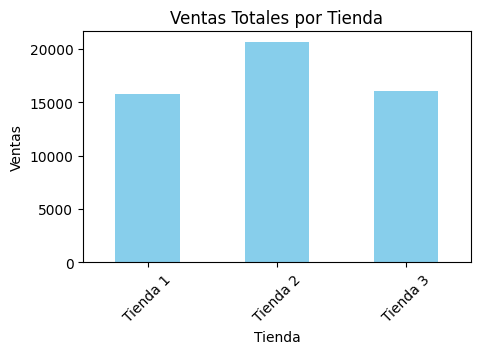

In [ ]:
#Visualización de los resultados
import matplotlib.pyplot as plt

# Sumar las ventas por tienda y graficar
ventas_por_tienda = cubo.groupby('Tienda')['Ventas'].sum()
ventas_por_tienda.plot(kind='bar', color='skyblue', figsize=(5, 3))

plt.title('Ventas Totales por Tienda')
plt.xlabel('Tienda')
plt.ylabel('Ventas')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#para hacer un roll-up con el campo fecha

# Crear una nueva columna para el mes (roll-up)
df['Mes'] = df['Fecha'].dt.to_period('M')  # Agregar columna 'Mes' para hacer el roll-up


# Crear el cubo con agregación por Región y Mes
cubo_rollup = pd.pivot_table(df,
                             values=['Ventas', 'Cantidad'],  # Medidas
                             index=['Region', 'Mes'],  # Dimensiones: Región y Mes
                             aggfunc={'Ventas': 'sum', 'Cantidad': 'sum'},  # Función de agregación
                             fill_value=0)  # Rellenar valores vacíos con 0

# Mostrar las primeras filas del cubo roll-up
cubo_rollup.head(10)


Cantidad       Ventas
Region Mes                           
Este   2024-01        27  3524.380142
       2024-02        15  3091.790352
       2024-03        40  5592.302082
       2024-04         2  1296.761595
Norte  2024-01        44  4447.984882
       2024-02        26  1859.872658
       2024-03        41  2713.637836
       2024-04        14   542.657169
Oeste  2024-01        43  4327.014720
       2024-02        65  6588.475578

In [ ]:
# Roll up
# Mostrar el cubo de ventas y cantidad agregadas por Región y Mes
cubo_rollup[['Ventas', 'Cantidad']].head(10)

Ventas  Cantidad
Region Mes                           
Este   2024-01  3524.380142        27
       2024-02  3091.790352        15
       2024-03  5592.302082        40
       2024-04  1296.761595         2
Norte  2024-01  4447.984882        44
       2024-02  1859.872658        26
       2024-03  2713.637836        41
       2024-04   542.657169        14
Oeste  2024-01  4327.014720        43
       2024-02  6588.475578        65

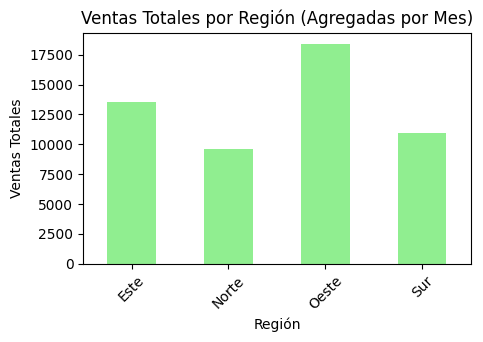

In [ ]:
import matplotlib.pyplot as plt

# Sumar las ventas por región a lo largo del tiempo
ventas_por_region_mes = cubo_rollup.groupby('Region')['Ventas'].sum()

# Graficar las ventas totales por región
ventas_por_region_mes.plot(kind='bar', color='lightgreen', figsize=(5, 3))
plt.title('Ventas Totales por Región (Agregadas por Mes)')
plt.xlabel('Región')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.show()


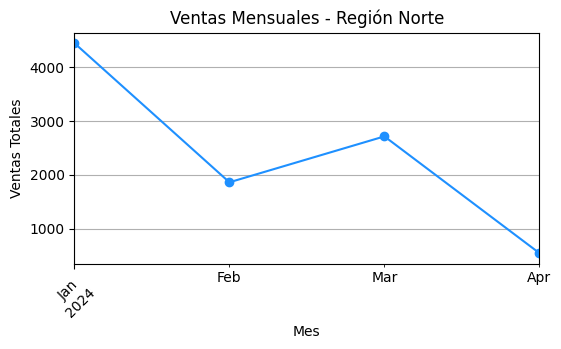

In [ ]:
# Filtrar las ventas por una región específica, por ejemplo, "Norte"
ventas_norte_por_mes = cubo_rollup.loc['Norte', 'Ventas']

# Graficar las ventas mensuales de la región "Norte"
ventas_norte_por_mes.plot(kind='line', marker='o', figsize=(6, 3), color='dodgerblue')
plt.title('Ventas Mensuales - Región Norte')
plt.xlabel('Mes')
plt.ylabel('Ventas Totales')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



---



---



# Example 2

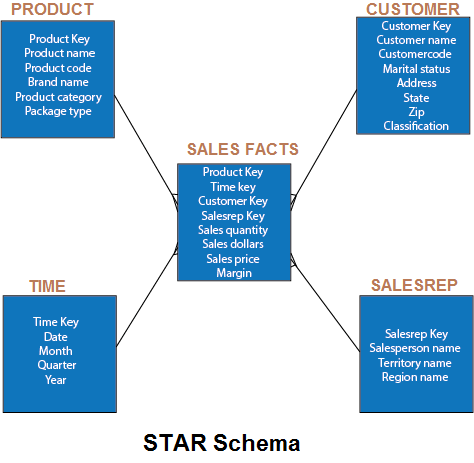


Tomado de: https://images.javatpoint.com/tutorial/datawarehouse/images/data-warehouse-what-is-snowflake-schema3.png

## Model
1. **Dimension Tables**

las tablas de dimensiones (por ejemplo, Cliente, Producto, Tiempo, Sucursal, Empleado) son las tablas de referencia que contienen información descriptiva sobre los hechos en el data warehouse. Estas tablas suelen tener una clave primaria y atributos que permiten describir mejor los datos de los hechos.

*  Dim_Cliente (contiene información sobre los clientes)
*  Dim_Producto (contiene detalles sobre productos)
*  Dim_Tiempo (detalles sobre fechas, horas, etc.)
*  Dim_Sucursal (información sobre las sucursales)
*  Dim_Empleado (información sobre los empleados)

*Subdimension*:
*  SubDim_Categoría (contiene detalle de las categorías de los productos)

Se crean los DataFrames para cada una de las tablas de dimensiones: Dim_Cliente, Dim_Producto, Dim_Tiempo, Dim_Sucursal, y Dim_Empleado. La tabla Dim_Producto tiene una relación con la tabla Dim_CategoriaProducto que simula la normalización.

2. **Fact Table**

La tabla de hechos es el núcleo del modelo. Contiene los registros transaccionales y, generalmente, las claves externas que hacen referencia a las tablas de dimensiones.

*  Fact_Ventas (almacena información sobre las ventas realizadas, con claves externas a las tablas de dimensiones)

In [ ]:
!pip install pandas


In [ ]:
# Esquema Copo de Nieve
import pandas as pd

# 1. Crear DataFrames para las tablas de dimensión

# Dimensión Cliente
data_cliente = {
    'ClienteID': [1, 2, 3, 4],
    'Nombre': ['Juan Perez', 'Ana Garcia', 'Luis Martinez', 'David Acosta'],
    'EstadoCivil': ['Soltero', 'Casado', 'Casado', 'Soltero'],
    'Direccion': ['Calle Falsa 123', 'Av. Reforma 456', 'Calle 25 789','Km 12 via Vcio'],
    'Ciudad': ['Madrid', 'Barcelona', 'Valencia', 'Villavicencio'],
    'Pais': ['España', 'España', 'España', 'Colombia']
}
dim_cliente = pd.DataFrame(data_cliente)

# Dimensión Producto
data_producto = {
    'ProductoID': [1, 2, 3],
    'NombreProducto': ['Laptop', 'Smartphone', 'Tablet'],
    'CategoriaID': [1, 2, 1],
    'Precio': [1200.50, 800.75, 450.30]
}
dim_producto = pd.DataFrame(data_producto)

# Subtabla Dim_CategoriaProducto (normalización)
data_categoria = {
    'CategoriaID': [1, 2],
    'CategoriaNombre': ['Electrónica', 'Móviles']
}
dim_categoria_producto = pd.DataFrame(data_categoria)

# Dimensión Tiempo
data_tiempo = {
    'TiempoID': [1, 2, 3, 4],
    'Fecha': ['2024-01-15', '2024-02-20', '2024-03-05','2024-02-22'],
    'Mes': [1, 2, 3, 2],
    'Año': [2024, 2024, 2024, 2024],
    'Trimestre': [1, 1, 1, 1]
}
dim_tiempo = pd.DataFrame(data_tiempo)

# Dimensión Sucursal
data_sucursal = {
    'SucursalID': [1, 2],
    'NombreSucursal': ['Sucursal A', 'Sucursal B'],
    'CiudadSucursal': ['Madrid', 'Barcelona'],
    'EstadoSucursal': ['Madrid', 'Catalunya']
}
dim_sucursal = pd.DataFrame(data_sucursal)

# Dimensión Empleado
data_empleado = {
    'EmpleadoID': [1, 2],
    'NombreEmpleado': ['Carlos Velandia', 'Sofia López'],
    'Cargo': ['Vendedor', 'Gerente'],
    'Departamento': ['Ventas', 'Gestión'],
    'Territorio': ['Madrid','Barcelona']
}
dim_empleado = pd.DataFrame(data_empleado)

# 2. Crear DataFrame para la tabla de hechos (Fact Table)

data_ventas = {
    'VentaID': [1, 2, 3, 4],
    'ClienteID': [1, 2, 3, 4],
    'ProductoID': [1, 2, 3, 1],
    'TiempoID': [1, 2, 3, 4],
    'SucursalID': [1, 2, 1, 1],
    'EmpleadoID': [1, 2, 1, 1],
    'Cantidad': [2, 1, 3, 2],
    'MontoTotal': [2401.00, 800.75, 1351.90, 2345.90]
}
fact_ventas = pd.DataFrame(data_ventas)

# 3. Relacionar las tablas de dimensiones con la tabla de hechos
# Para hacerlo, vamos a usar el método 'merge' de pandas para realizar joins en las tablas.

# Relacionar Dim_Producto con Dim_CategoriaProducto
dim_producto = dim_producto.merge(dim_categoria_producto, on='CategoriaID', how='left')

# Relacionar Fact_Ventas con Dim_Cliente
fact_ventas = fact_ventas.merge(dim_cliente, on='ClienteID', how='left')

# Relacionar Fact_Ventas con Dim_Producto
fact_ventas = fact_ventas.merge(dim_producto, on='ProductoID', how='left')

# Relacionar Fact_Ventas con Dim_Tiempo
fact_ventas = fact_ventas.merge(dim_tiempo, on='TiempoID', how='left')

# Relacionar Fact_Ventas con Dim_Sucursal
fact_ventas = fact_ventas.merge(dim_sucursal, on='SucursalID', how='left')

# Relacionar Fact_Ventas con Dim_Empleado
fact_ventas = fact_ventas.merge(dim_empleado, on='EmpleadoID', how='left')



# Mostrar las tablas resultantes
print("Tabla de Dim_Cliente:")
print(dim_cliente)
print("\nTabla de Dim_Producto:")
print(dim_producto)
print("\nTabla de Dim_Tiempo:")
print(dim_tiempo)
print("\nTabla de Dim_Sucursal:")
print(dim_sucursal)
print("\nTabla de Dim_Empleado:")
print(dim_empleado)
print("\nTabla de Fact_Ventas (con joins):")
print(fact_ventas)



Tabla de Dim_Cliente:
   ClienteID         Nombre EstadoCivil        Direccion         Ciudad  \
0          1     Juan Perez     Soltero  Calle Falsa 123         Madrid   
1          2     Ana Garcia      Casado  Av. Reforma 456      Barcelona   
2          3  Luis Martinez      Casado     Calle 25 789       Valencia   
3          4   David Acosta     Soltero   Km 12 via Vcio  Villavicencio   

       Pais  
0    España  
1    España  
2    España  
3  Colombia  

Tabla de Dim_Producto:
   ProductoID NombreProducto  CategoriaID   Precio CategoriaNombre
0           1         Laptop            1  1200.50     Electrónica
1           2     Smartphone            2   800.75         Móviles
2           3         Tablet            1   450.30     Electrónica

Tabla de Dim_Tiempo:
   TiempoID       Fecha  Mes   Año  Trimestre
0         1  2024-01-15    1  2024          1
1         2  2024-02-20    2  2024          1
2         3  2024-03-05    3  2024          1
3         4  2024-02-22    2  2024

In [ ]:
fact_ventas.columns

Index(['VentaID', 'ClienteID', 'ProductoID', 'TiempoID', 'SucursalID',
       'EmpleadoID', 'Cantidad', 'MontoTotal', 'Nombre', 'EstadoCivil',
       'Direccion', 'Ciudad', 'Pais', 'NombreProducto', 'CategoriaID',
       'Precio', 'CategoriaNombre', 'Fecha', 'Mes', 'Año', 'Trimestre',
       'NombreSucursal', 'CiudadSucursal', 'EstadoSucursal', 'NombreEmpleado',
       'Cargo', 'Departamento', 'Territorio'],
      dtype='object')

##Operations OLAP

*  Roll-up: Agrupa los datos en un nivel más alto de detalle, por ejemplo, las ventas por mes y año.


*  Drill-down: Desglosa los datos en un nivel más detallado, como las ventas por cliente y producto.

*  Slice: Extrae una parte de los datos para analizar un solo subconjunto, como las ventas de un mes específico.

*  Dice: Filtra los datos en varias dimensiones, permitiendo una vista más compleja, como las ventas de productos electrónicos en un mes específico.


Estas operaciones son fundamentales para realizar un análisis multidimensional eficaz y aprovechar al máximo las capacidades del Data Warehouse.

Más información: https://www.javatpoint.com/olap-operations

Para un Data Warehouse o modelo de datos multidimensional como el que hemos creado, las operaciones de roll-up, drill-down, slice, y dice son esenciales para realizar análisis en diferentes niveles de detalle o para explorar los datos de diversas formas. Vamos a explicar cómo aplicar cada una de estas operaciones utilizando los dataframes que hemos creado en Python.

##1. Roll-up (Agrupar datos en un nivel superior)
El Roll-up es una operación que permite agregar datos y verlos a un nivel de detalle más alto. Esto implica agrupar datos a un nivel superior, resumiendo la información.

Ejemplo: Roll-up de ventas por mes (sin importar el cliente o el producto)
Podemos realizar un roll-up en el conjunto de datos de Fact_Ventas para ver las ventas totales por mes y año, sin tener en cuenta la información del cliente o del producto.

In [ ]:
# Roll-up: Ventas por mes y año
rollup_ventas_mes = fact_ventas.groupby(['Mes', 'Año'])['MontoTotal'].sum().reset_index()

print("Ventas agregadas por Mes y Año (Roll-up):")
print(rollup_ventas_mes)


Ventas agregadas por Mes y Año (Roll-up):
   Mes   Año  MontoTotal
0    1  2024     2401.00
1    2  2024     3146.65
2    3  2024     1351.90


##2. Drill-down (Desglosar datos en un nivel más detallado)
El Drill-down es lo opuesto a Roll-up. Permite ver los datos a un nivel más detallado, es decir, desglosar un resumen para obtener información más precisa.

Ejemplo: Drill-down de ventas por cliente y producto (más detalles)
En este caso, queremos obtener las ventas desglosadas por ClienteID y ProductoID en lugar de agruparlas solo por mes.

In [ ]:
# Drill-down: Ventas por Cliente y Producto
drilldown_ventas_cliente_producto = fact_ventas.groupby(['ClienteID', 'ProductoID'])['MontoTotal'].sum().reset_index()

print("Ventas desglosadas por Cliente y Producto (Drill-down):")
print(drilldown_ventas_cliente_producto)


Ventas desglosadas por Cliente y Producto (Drill-down):
   ClienteID  ProductoID  MontoTotal
0          1           1     2401.00
1          2           2      800.75
2          3           3     1351.90
3          4           1     2345.90


##3. Slice (Corte de datos en una sola dimensión)
El Slice consiste en "cortar" los datos en una dimensión específica, es decir, seleccionar un subconjunto de los datos para ver una vista específica.

Ejemplo: Slice de ventas de un solo mes
Supongamos que estamos interesados solo en las ventas de febrero de 2024. Usamos slice para seleccionar este subconjunto de datos, enfocándonos solo en ese mes.

In [ ]:
# Slice: Filtrar datos solo para el mes de febrero (Mes = 2)
slice_febrero = fact_ventas[fact_ventas['Mes'] == 2]

print("Ventas en febrero de 2024 (Slice):")
print(slice_febrero)


Ventas en febrero de 2024 (Slice):
   VentaID  ClienteID  ProductoID  TiempoID  SucursalID  EmpleadoID  Cantidad  \
1        2          2           2         2           2           2         1   
3        4          4           1         4           1           1         2   

   MontoTotal        Nombre EstadoCivil  ... Mes   Año Trimestre  \
1      800.75    Ana Garcia      Casado  ...   2  2024         1   
3     2345.90  David Acosta     Soltero  ...   2  2024         1   

  NombreSucursal  CiudadSucursal  EstadoSucursal   NombreEmpleado     Cargo  \
1     Sucursal B       Barcelona       Catalunya      Sofia López   Gerente   
3     Sucursal A          Madrid          Madrid  Carlos Velandia  Vendedor   

   Departamento  Territorio  
1       Gestión   Barcelona  
3        Ventas      Madrid  

[2 rows x 28 columns]


##4. Dice (Filtro de datos en varias dimensiones)
El Dice es una operación más compleja que combina slice y roll-up. Permite cortar los datos en varias dimensiones y ver el resultado en una "subcubierta" de datos.

Ejemplo: Dice de ventas de febrero y solo para productos de categoría 'Electrónica'
Aquí queremos ver las ventas realizadas en febrero de 2024 para productos de la categoría 'Electrónica'. Para esto, filtramos tanto por Mes como por CategoriaNombre.

In [ ]:
# Dice: Filtrar datos para el mes de febrero y solo para productos de categoría 'Electrónica'

# Ahora, realizar la operación Dice: Filtrar datos para el mes de febrero y solo para productos de la categoría 'Electrónica'
dice_febrero_electronica = fact_ventas[(fact_ventas['Mes'] == 2) & (fact_ventas['CategoriaID'] == 1)]

print("Ventas en febrero de 2024 para productos de categoría 'Electrónica' (Dice):")
print(dice_febrero_electronica)


Ventas en febrero de 2024 para productos de categoría 'Electrónica' (Dice):
   VentaID  ClienteID  ProductoID  TiempoID  SucursalID  EmpleadoID  Cantidad  \
3        4          4           1         4           1           1         2   

   MontoTotal        Nombre EstadoCivil  ... Mes   Año Trimestre  \
3      2345.9  David Acosta     Soltero  ...   2  2024         1   

  NombreSucursal  CiudadSucursal  EstadoSucursal   NombreEmpleado     Cargo  \
3     Sucursal A          Madrid          Madrid  Carlos Velandia  Vendedor   

   Departamento  Territorio  
3        Ventas      Madrid  

[1 rows x 28 columns]


##Usando las pivot_table

El parámetro aggfunc en las pivot tables de Pandas permite especificar qué función de agregación se debe aplicar a los datos cuando se agrupan por las dimensiones seleccionadas.

Funciones comunes para aggfunc
*   sum: Suma de los valores.
aggfunc='sum'
*   mean: Promedio de los valores.
aggfunc='mean'
*   count: Cuenta el número de elementos no nulos.
aggfunc='count'
*   min: Valor mínimo de los valores.
aggfunc='min'
*   max: Valor máximo de los valores.
aggfunc='max'
*   std: Desviación estándar de los valores.
aggfunc='std'
*   var: Varianza de los valores.
aggfunc='var'
*   median: Mediana de los valores.
aggfunc='median'
*   first: Primer valor de cada grupo.
aggfunc='first'
*   last: Último valor de cada grupo.
aggfunc='last'
*   nunique: Número de valores únicos.
aggfunc='nunique'
*   apply: Aplicar una función personalizada.
Ejemplo: Usar una función personalizada para calcular algo más complejo.
aggfunc=custom_func
```
def custom_func(x):
    return x.max() - x.min()
```
*   sum y mean combinados (usando diccionarios): Puedes aplicar diferentes funciones de agregación a diferentes columnas especificando un diccionario. Por ejemplo, sumar el MontoTotal y calcular el promedio de las Cantidades.
```
aggfunc={'MontoTotal': 'sum', 'Cantidad': 'mean'}
quantile: Cuantiles (por ejemplo, percentiles).
```
Ejemplo: Obtener el cuartil 90 del MontoTotal.
```
aggfunc=lambda x: x.quantile(0.9)
```
*   prod: Producto de los valores.
Ejemplo: Multiplicar todos los valores en el grupo.
aggfunc='prod'

In [ ]:
# Pivot table con márgenes para calcular subtotales por Cliente
pivot_cliente = pd.pivot_table(fact_ventas,
                               values='MontoTotal',
                               index=['ClienteID', 'Nombre'],
                               aggfunc='sum',
                               margins=True,
                               margins_name='Total')

print("Subtotal por Cliente (Pivot Table con márgenes):")
print(pivot_cliente)

Subtotal por Cliente (Pivot Table con márgenes):
                         MontoTotal
ClienteID Nombre                   
1         Juan Perez        2401.00
2         Ana Garcia         800.75
3         Luis Martinez     1351.90
4         David Acosta      2345.90
Total                       6899.55


In [ ]:
# Pivot table con márgenes para calcular subtotales por Producto
pivot_producto = pd.pivot_table(fact_ventas,
                                values='MontoTotal',
                                index=['ProductoID', 'NombreProducto'],
                                aggfunc='sum',
                                margins=True,
                                margins_name='Total')

print("\nSubtotal por Producto (Pivot Table con márgenes):")
print(pivot_producto)


Subtotal por Producto (Pivot Table con márgenes):
                           MontoTotal
ProductoID NombreProducto            
1          Laptop             4746.90
2          Smartphone          800.75
3          Tablet             1351.90
Total                         6899.55


In [ ]:
# Pivot table con márgenes para calcular subtotales por Mes y Año
pivot_tiempo = pd.pivot_table(fact_ventas,
                              values='MontoTotal',
                              index=['Mes', 'Año'],
                              aggfunc='sum',
                              margins=True,
                              margins_name='Total')

print("\nSubtotal por Mes y Año (Pivot Table con márgenes):")
print(pivot_tiempo)


Subtotal por Mes y Año (Pivot Table con márgenes):
            MontoTotal
Mes   Año             
1     2024     2401.00
2     2024     3146.65
3     2024     1351.90
Total          6899.55


In [ ]:
# Pivot table con márgenes para calcular subtotales por Sucursal
pivot_sucursal = pd.pivot_table(fact_ventas,
                                values='MontoTotal',
                                index=['SucursalID', 'NombreSucursal'],
                                aggfunc='sum',
                                margins=True,
                                margins_name='Total')

print("\nSubtotal por Sucursal (Pivot Table con márgenes):")
print(pivot_sucursal)



Subtotal por Sucursal (Pivot Table con márgenes):
                           MontoTotal
SucursalID NombreSucursal            
1          Sucursal A         6098.80
2          Sucursal B          800.75
Total                         6899.55


In [ ]:
# Pivot table con márgenes para calcular subtotales por Empleado
pivot_empleado = pd.pivot_table(fact_ventas,
                                values='MontoTotal',
                                index=['EmpleadoID', 'NombreEmpleado'],
                                aggfunc='sum',
                                margins=True,
                                margins_name='Total')

print("\nSubtotal por Empleado (Pivot Table con márgenes):")
print(pivot_empleado)



Subtotal por Empleado (Pivot Table con márgenes):
                            MontoTotal
EmpleadoID NombreEmpleado             
1          Carlos Velandia     6098.80
2          Sofia López          800.75
Total                          6899.55


In [ ]:
#Promedio de las ventas por cada producto
pivot_producto = pd.pivot_table(fact_ventas,
                                values='MontoTotal',
                                index=['ProductoID', 'NombreProducto'],
                                aggfunc='mean',
                                margins=True,
                                margins_name='Promedio')
print("\nPromedio por Producto (Pivot Table con margin):")
print(pivot_producto)


Promedio por Producto (Pivot Table con margin):
                           MontoTotal
ProductoID NombreProducto            
1          Laptop           2373.4500
2          Smartphone        800.7500
3          Tablet           1351.9000
Promedio                    1724.8875


In [ ]:
pivot_empleado = pd.pivot_table(fact_ventas,
                                values='MontoTotal',
                                index=['EmpleadoID', 'NombreEmpleado'],
                                aggfunc='std',
                                margins=True,
                                margins_name='Desviación Estándar')


## Usando Base de Datos

In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")
fact_ventas.to_sql("ventas", conn, if_exists="replace", index=False)


4

In [ ]:
# Dice: Filtrar datos para el mes de febrero y solo para productos de categoría 'Electrónica'

query1 = """
SELECT *
FROM ventas
WHERE Mes = 2 AND CategoriaID = 1;
"""
dice_febrero_electronica = pd.read_sql_query(query1, conn)
print("Ventas en febrero de 2024 para productos de categoría 'Electrónica' (Dice):")
print(dice_febrero_electronica)

Ventas en febrero de 2024 para productos de categoría 'Electrónica' (Dice):
   VentaID  ClienteID  ProductoID  TiempoID  SucursalID  EmpleadoID  Cantidad  \
0        4          4           1         4           1           1         2   

   MontoTotal        Nombre EstadoCivil  ... Mes   Año Trimestre  \
0      2345.9  David Acosta     Soltero  ...   2  2024         1   

  NombreSucursal  CiudadSucursal  EstadoSucursal   NombreEmpleado     Cargo  \
0     Sucursal A          Madrid          Madrid  Carlos Velandia  Vendedor   

   Departamento  Territorio  
0        Ventas      Madrid  

[1 rows x 28 columns]


In [ ]:
query2 = """
SELECT Mes, Año, SUM(MontoTotal) AS MontoTotal
FROM ventas
GROUP BY Mes, Año;
"""

print("Subtotal por mes y año \n",pd.read_sql_query(query2, conn))


Subtotal por mes y año 
    Mes   Año  MontoTotal
0    1  2024     2401.00
1    2  2024     3146.65
2    3  2024     1351.90


# Desafío OLAP con SQLite


## Mini-Desafío

Ahora que has aprendido sobre los conceptos de Data Warehousing y OLAP, y has visto cómo realizar algunas operaciones básicas en Pandas y SQLite, ¡es hora de un desafío!

**El desafío:**

Utilizando la tabla `ventas` que creamos en la base de datos SQLite en memoria, realiza las siguientes operaciones OLAP utilizando consultas SQL:

1.  **Roll-up:** Calcula la suma total de `Cantidad` vendida por `CategoriaNombre` y `Mes` y ordenada de manera descendente.
2.  **Dice:** Filtra los datos para mostrar las ventas (`MontoTotal`) de "Producto A" realizadas en la "Sucursal A".
3.  **Drill-down:** Muestre las `Ventas` por `Cliente`, `Producto` y `Fecha`, ordenada por fecha
4.  **Slice:** Ventas de un producto específico (por ejemplo, 'Laptop')
5.  **Dice** indique las ventas totales y ventas promedio por ciudad de la sucursal e indique el empleado que más ventas realiza

¡Inténtalo por tu cuenta primero! Si necesitas una pista, puedes retomar las consultas anteriores como referencia.


# Desafío

Construya un modelo de esquema tipo Estrella para las operaciones OLAP a partir del siguiente conjunto de datos, recuerde realizar el preprocesamiento de datos según corresponda, y para valores perdidos realice imputación de valores con la mediana.


El conjunto de datos contiene una lista de videojuegos con ventas superiores a 100,000 copias.

Los campos incluyen:
*   Rank - Ranking of overall sales (Ranking de ventas globales)
*   Name - The games name (El nombre del juego)
*   Platform - Platform of the games release (i.e. PC,PS4, etc.) (Plataforma de lanzamiento de los juegos (es decir. PC,PS4, etc.))
*   Year - Year of the game's release (Año de lanzamiento del juego)
*   Genre - Genre of the game (Género del juego)
*   Publisher - Publisher of the game (Editor del juego)
*   NA_Sales - Sales in North America (in millions) (Ventas en América del Norte (en millones))
*   EU_Sales - Sales in Europe (in millions) (Ventas en Europa)
*   JP_Sales - Sales in Japan (in millions) (Ventas en Japón (en millones))
*   Other_Sales - Sales in the rest of the world (in millions) (Ventas en el resto del mundo)
*   Global_Sales - Total worldwide sales. (Ventas totales a nivel mundial.)

Descargue el .zip de: https://drive.google.com/file/d/1PgBbyXOvdNi4s6tNLELJoYnmq_G_nECp/

Realice las siguientes consultas y operaciones del cubo de datos:

*   Consulte las ventas totales por género de los videojuegos
*   Sume la venta total del "Genre" == "Action"
*   Calcule el valor promedio de ventas por año, el precio mínimo por año y el precio máximo por año según el Editor del juego y presente el resultado del valor promedio por año por editor en un gráfico.
*   Obtenga las ventas por trimestre en el último año para Estados Unidos, Japón y Europa
*   Precise el nombre del juego y el género que más ventas globales genera.


# Desafío2

The example data used here is the International Bank for Reconstruction and Development (IBRD) Balance Sheet. The CSV file (https://cubes.readthedocs.io/en/v1.0.1/_downloads/IBRD_Balance_Sheet__FY2010.csv) includes records that are characterized by a Category (and subcategories), Line Item, Fiscal Year, and Amount (in US$ millions). Start with imports:

                      "BRD_Balance_Sheet__FY2010.csv",
                      table_name="ibrd_balance",
                      fields=[
                          ("category", "string"),
                          ("category_label", "string"),
                          ("subcategory", "string"),
                          ("subcategory_label", "string"),
                          ("line_item", "string"),
                          ("year", "integer"),
                          ("amount", "integer")

In [ ]:
csv_file_path = '/content/drive/My Drive/2024-1/Clases Comp3 -Intro Analítica de Datos/Laboratorios/Cube _OLAP/IBRD_Balance_Sheet__FY2010.csv'

Lea el archivo: IBRD_Balance_Sheet__FY2010.csv

*  Define the data model (utilice sqlite3)

*  Realice operaciones OLAP:

1.  Drill-down: Get detailed data for category, and show detail data for a specific category = 'Long Term Debt'

2.  Roll-up: Summarize data at a higher level

3.  Slice and Dice: select a point cut by fiscal year = FY2010

More info:

Building a Data Warehouse in Python Using PostgreSQL:
https://towardsdatascience.com/building-a-data-warehouse-in-python-using-postgresql-f10dce22e3aa